# 03 · Train a policy and a fallible verifier

Created by Shivam Bharadwaj · [Build GoalLab](../README.md) · [Protocol](../PROTOCOL.md)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/build-goallab/notebooks/03_ppo_and_verifier.ipynb)

**Question:** can verification help a policy decide whether to keep investigating?

You will train PPO, fit a separate support-aware verifier, and test the cost of consulting it. Think of the verifier as a reviewer who can also be mistaken: its score is evidence for a decision, not the final answer key.

**Prerequisites:** course notebooks 06–07. **Outcome:** a frozen policy, a train-only verifier, and a comparison that includes scoring cost.

![The investigation loop and independent final evaluation](../architecture.svg)

**Run:** restart the kernel and run all cells. Each lab is independent. The default uses CPU, no API key, and no pretrained-model download. Colab runs need the published repository revision. Code is MIT; educational text and plots are CC BY 4.0.

In [1]:
import sys, subprocess, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p/'rl_course/goallab_benchmark.py').exists()), None)
if ROOT is None and IN_COLAB:
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git','clone','--depth','1','https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git',str(ROOT)],check=True)
    subprocess.run([sys.executable,'-m','pip','install','-q','numpy','matplotlib','torch'],check=True)
if ROOT is None or not (ROOT/'rl_course/goallab_benchmark.py').exists():
    raise FileNotFoundError('Use the full repository revision containing GoalLab-v2.')
sys.path.insert(0,str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import display, Markdown
from rl_course import goallab_benchmark as g, goallab_training as train
torch.set_num_threads(2)
ARTIFACTS = Path(tempfile.mkdtemp(prefix='goallab-lab-'))
plt.rcParams.update({'figure.figsize':(9,4),'figure.facecolor':'#f5f1e8','axes.facecolor':'#f5f1e8',
    'axes.spines.top':False,'axes.spines.right':False,'axes.prop_cycle':plt.cycler(color=['#af824a','#657951','#87708c','#292332'])})
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+'|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(str(v) for v in row)+' |' for row in rows)))
print(g.VERSION, '| Torch',torch.__version__, '| device: CPU | artifacts:',ARTIFACTS)

GoalLab-v2 | Torch 2.11.0+cu130 | device: CPU | artifacts: /tmp/goallab-lab-oewlkzxr


## 1. Separate three different signals

The policy chooses an action. Its critic estimates discounted return. The learned verifier predicts whether a proposed answer is correct and supported by collected evidence. The final evaluator grades the completed episode using the private key. Only the first three components can guide inference.

For a PPO ratio 1.4 and advantage 2, clipping at 1.2 yields a surrogate of 2.4 instead of 2.8. This clips the objective; it does not guarantee the resulting policy distribution stays inside a hard trust region.

In [2]:
ratio,advantage,epsilon=1.4,2.,.2
print('Clipped surrogate:',min(ratio*advantage,np.clip(ratio,1-epsilon,1+epsilon)*advantage))
import inspect
print(inspect.getsource(train.train_ppo))

Clipped surrogate: 2.4
def train_ppo(seed=7, episodes=1200, group_relative=False):
    """Clipped PPO with GAE; optional same-case, group-relative trajectory updates.

    The latter is a small discrete-policy GRPO-style exercise, not LLM GRPO.
    Neither routine uses demonstrations or evaluation split labels.
    """
    torch.manual_seed(seed)
    rng = random.Random(seed)
    model = Controller()
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    history, steps = [], 0
    for first in range(0, episodes, 24):
        batch, trajectory_returns = [], []
        shared = None
        for j in range(min(24, episodes-first)):
            if not group_relative or j % 6 == 0:
                shared = training_case(rng)
            env = deepcopy(shared)
            trajectory = []
            while not env.done:
                obs = env.observation()
                x, valid = tensors(obs)
                with torch.no_grad():
                    logits, value = model(x)
 

## 2. Train PPO on complete episodes

Complete episodes let the return calculation terminate without an artificial time-limit bootstrap. GAE trades variance against bias, while entropy discourages immediate collapse. The implementation clips gradients and stops repeated epochs after a large approximate KL. These precautions still do not guarantee useful exploration.

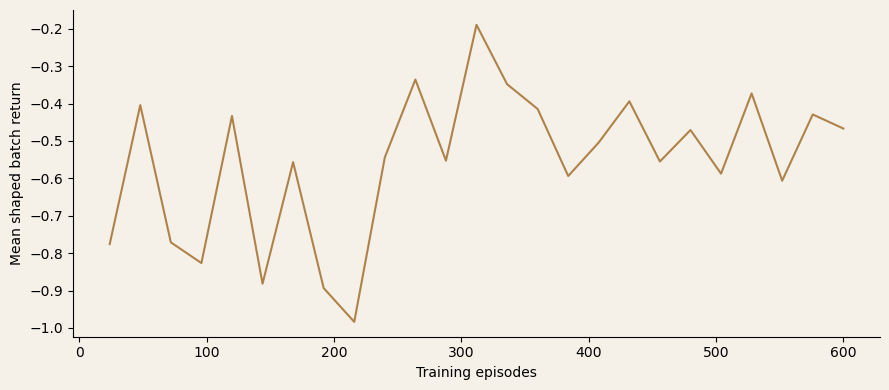

Policy parameters: 12832


In [3]:
EPISODES=600
policy,history=train.train_ppo(seed=7,episodes=EPISODES)
plt.plot([r['episode'] for r in history['history']],[r['return'] for r in history['history']]);plt.xlabel('Training episodes');plt.ylabel('Mean shaped batch return');plt.tight_layout();plt.show()
print('Policy parameters:',sum(p.numel() for p in policy.parameters()))

## 3. Fit the verifier using Train only

The label is joint correctness and observed support. Examples include partial investigations and unsupported candidates. Training it on final Test results would leak evaluation into the decision process. The model uses a 32-unit hidden layer; its probabilities still need calibration checks.

Predict: a correct answer without an inspected citation should receive a negative training label.

In [4]:
verifier,info=train.train_verifier(seed=7,cases=300)
print(info)
case=g.make_case(20,'GoalLab-Test',4)
env=g.Investigation(case,8)
print('Scores before investigation:',train.scores(verifier,env.observation()).round(3))
env.step(g.AUTHORITY)
print('Scores after paid authoritative evidence:',train.scores(verifier,env.observation()).round(3))

{'training_cases': 300, 'examples': 4167, 'epochs': 30, 'positive_fraction': 0.06335493177175522}
Scores before investigation: [0.001 0.    0.001]
Scores after paid authoritative evidence: [0.322 0.422 0.228]


## 4. Verification is not free

PPO + Verifier pays one work unit for each learned score query. Its fixed threshold is 0.65; below that threshold it continues with PPO's non-STOP actions. A verifier can consume the budget needed to gather evidence. Compare coverage, verified success, and total cost together.

In [5]:
records=[]
for method in ['PPO','PPO + Verifier']:
    for i in range(40):
        env=train.investigate(g.make_case(i,'GoalLab-Test',i%5+1),method,8,policy,verifier)
        records.append(train.record(env,method,7))
table(['Method','Success','Coverage','Cost','Brier'],[[r['method'],f"{r['success']:.1%}",f"{r['answer_coverage']:.1%}",round(r['average_cost'],2),r['brier']] for r in train.aggregate(records)])

| Method | Success | Coverage | Cost | Brier |
|---|---|---|---|---|
| PPO | 0.0% | 0.0% | 7.0 | None |
| PPO + Verifier | 100.0% | 100.0% | 8.0 | 0.0025000000000000044 |

## 5. Change the training signal: optional group-relative experiment

The variant samples six complete trajectories from the same case, normalizes their returns within the group, and uses a clipped policy objective. The critic is trained but its GAE is not used for the actor in this variant. This isolates group-relative mechanics on a discrete controller; it is not an implementation of pretrained-LLM GRPO.

Set `RUN_GROUP_EXPERIMENT=True` to compare it. Hold training episodes and evaluation cases fixed, but also report actual action counts because trajectory lengths differ.

In [6]:
RUN_GROUP_EXPERIMENT=False
if RUN_GROUP_EXPERIMENT:
    grouped,group_info=train.train_ppo(seed=7,episodes=EPISODES,group_relative=True)
    results=[train.investigate(g.make_case(i,'GoalLab-Test',i%5+1),'PPO',8,grouped) for i in range(40)]
    print('Group-relative verified success:',np.mean([g.verify(e.case,e.artifact,e.observation())['success'] for e in results]))
    print('PPO actions:',history['actions'],'Group actions:',group_info['actions'])
else:
    print('Optional group experiment is disabled; no group-training result is claimed.')

Optional group experiment is disabled; no group-training result is claimed.


## Interpret the result

A policy can improve its reward by abstaining when random answers are penalized. That is a valid response to the reward but a failure to solve the user's task. The repository preserves a failed pre-shaping run for this reason. Reward shaping should be derived from observable progress and set to zero at termination; evaluation must still use verified completion.

**Next:** [Evaluation and search](04_evaluation_and_search.ipynb).